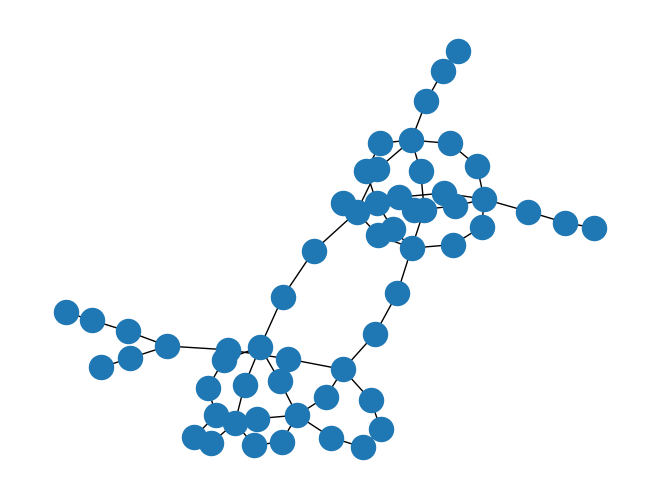

In [6]:
from pathlib import Path
from time import perf_counter
from pprint import pprint
import numpy as np
import time
import json
# from collections import defaultdict
from copy import copy, deepcopy

input_path = 'input_chris.txt'
# input_path = Path(f'{__file__}/../input_example.txt').resolve()
# input_path = Path(f'{__file__}/../input_chris.txt').resolve()

time_start = perf_counter()

with open(input_path, 'r') as f:
    data = f.readlines()

flows = {}
leads = {}

for line in data:
    valve = line.split(' has')[0].split('Valve ')[1]
    flow = int(line.split('=')[1].split(';')[0])
    lead = line.split("valv")[-1].strip()
    lead = [c.strip(',') for c in lead.split(' ')[1:]]

    flows[valve] = flow
    leads[valve] = lead
    # print(valve, flow, lead)

# Reduce graph, remove 0 nodes.

# new_leads = {}
# for node, lead in leads.items():
#     new_leads[node] = {l:1 for l in lead}

# pprint(flows)
# leads = deepcopy(new_leads)
# Find distance from node to every other node
import networkx as nx

G = nx.Graph()
G.add_nodes_from(list(leads.keys()))
for node, lead in leads.items():
    for l in lead:
        G.add_edge(node, l)

nx.draw(G)

In [7]:
lengths = nx.all_pairs_shortest_path(G)
leads = {}
for item in lengths:
    # print(item[1])
    leads[item[0]] = {k: len(v)-1 for k, v in item[1].items()}
    leads[item[0]].pop(item[0])

for k in list(leads.keys()):
    for k2 in list(leads[k].keys()):
        if flows[k2] == 0:
            leads[k].pop(k2)
    if k == 'AA':
        temp_aa = leads['AA']
    if flows[k] == 0:
        leads.pop(k)
leads['AA'] = temp_aa

pprint(leads)

{'AA': {'AK': 6,
        'BF': 7,
        'BV': 2,
        'CN': 5,
        'DS': 2,
        'GB': 6,
        'GL': 11,
        'IC': 3,
        'JH': 8,
        'KM': 2,
        'KT': 5,
        'NK': 5,
        'NT': 3,
        'OE': 5,
        'XC': 10},
 'AK': {'BF': 5,
        'BV': 8,
        'CN': 11,
        'DS': 7,
        'GB': 12,
        'GL': 10,
        'IC': 9,
        'JH': 7,
        'KM': 8,
        'KT': 2,
        'NK': 3,
        'NT': 3,
        'OE': 4,
        'XC': 9},
 'BF': {'AK': 5,
        'BV': 7,
        'CN': 11,
        'DS': 5,
        'GB': 11,
        'GL': 8,
        'IC': 8,
        'JH': 5,
        'KM': 8,
        'KT': 3,
        'NK': 6,
        'NT': 5,
        'OE': 2,
        'XC': 7},
 'BV': {'AK': 8,
        'BF': 7,
        'CN': 6,
        'DS': 2,
        'GB': 6,
        'GL': 11,
        'IC': 3,
        'JH': 8,
        'KM': 3,
        'KT': 7,
        'NK': 7,
        'NT': 5,
        'OE': 5,
        'XC': 10},
 'CN': {'AK': 11,


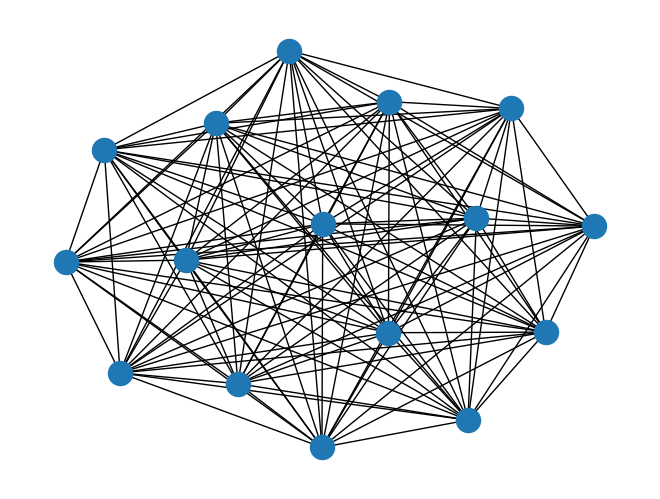

In [9]:
G = nx.Graph()
G.add_nodes_from(list(leads.keys()))
for node, lead in leads.items():
    for l in lead:
        G.add_edge(node, l)
nx.draw(G)